In [13]:
import pandas as pd
import numpy as np 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

def data_integrity_check(df):                                                  
    target_columns = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
    for col in target_columns:
        if col in df.columns:
            signal = df[col].values
            report[col] = {
                "NaN_count": int(np.isnan(signal).sum()),
                "Inf_count": int(np.isinf(signal).sum()),
                "Zero_count": int(np.sum(signal == 0)),
                "Total_samples": len(signal)
            }
    return report

MASTER_FILE = 'combined_dataset_cleaned.csv'                                 

if os.path.exists(MASTER_FILE):
    print(f"Found existing master dataset: '{MASTER_FILE}'. Loading directly...")
    combined_df = pd.read_csv(MASTER_FILE)
    
    print("\n MASTER DATASET INFO")
    print("Columns:", list(combined_df.columns))
    print("Shape:", combined_df.shape)
    print(f"GRAND TOTAL SAMPLES: {len(combined_df)}\n")
    
    print("Data Integrity Report (Current Master)")
    current_report = data_integrity_check(combined_df)
    for col_name, stats in current_report.items():
        print(f"{col_name}: {stats}")
    print("\n")
    
else:
    print(f"'{MASTER_FILE}' not found. Processing the initial 5 datasets...")
    csv_files = ['dataset1.csv', 'dataset2.csv', 'dataset3.csv', 'dataset4.csv', 'dataset5.csv']
    
    dataframes = [pd.read_csv(file) for file in csv_files]
    combined_df = pd.concat(dataframes, ignore_index=True)

    print("\n COMBINED DATASET INFO")
    print("Columns:", list(combined_df.columns))
    print("Shape:", combined_df.shape)
    print(f"GRAND TOTAL SAMPLES: {len(combined_df)}\n")

    print(" Data Integrity Report (Before Cleaning)")
    initial_report = data_integrity_check(combined_df)
    for col_name, stats in initial_report.items():
        print(f"{col_name}: {stats}")
    print("\n")

    target_columns = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
    for col in target_columns:
        if col in combined_df.columns:
            combined_df[col] = combined_df[col].replace(0, np.nan)

    combined_df = combined_df.replace([np.inf, -np.inf], np.nan)
    combined_df = combined_df.dropna()

    print("Data Integrity Report (After Full Cleaning)")
    final_report = data_integrity_check(combined_df)
    for col_name, stats in final_report.items():
        print(f"{col_name}: {stats}")
    print(f"\nFinal dataset shape after dropping missing values: {combined_df.shape}\n")

    combined_df.to_csv(MASTER_FILE, index=False)
    print(f"Saved fully cleaned dataset to '{MASTER_FILE}' successfully!")

Found existing master dataset: 'combined_dataset_cleaned.csv'. Loading directly...

 MASTER DATASET INFO
Columns: ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'Fault class']
Shape: (1320, 6)
GRAND TOTAL SAMPLES: 1320

Data Integrity Report (Current Master)
H2: {'NaN_count': 0, 'Inf_count': 0, 'Zero_count': 0, 'Total_samples': 1320}
CH4: {'NaN_count': 0, 'Inf_count': 0, 'Zero_count': 0, 'Total_samples': 1320}
C2H6: {'NaN_count': 0, 'Inf_count': 0, 'Zero_count': 0, 'Total_samples': 1320}
C2H4: {'NaN_count': 0, 'Inf_count': 0, 'Zero_count': 0, 'Total_samples': 1320}
C2H2: {'NaN_count': 0, 'Inf_count': 0, 'Zero_count': 0, 'Total_samples': 1320}




In [14]:
print(f"Total samples available for training after dropping NaNs: {len(combined_df)}\n")
feature_cols = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
X = combined_df[feature_cols]
y = combined_df['Fault class']  

Total samples available for training after dropping NaNs: 1320



C:\Users\kaviy\AppData\Local\Temp\ipykernel_2732\4252002756.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Gas', data=feature_importance_df, palette='viridis')


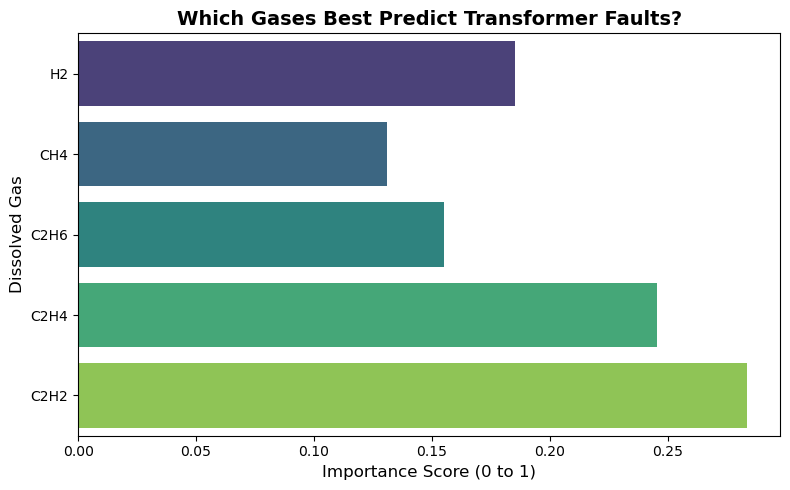

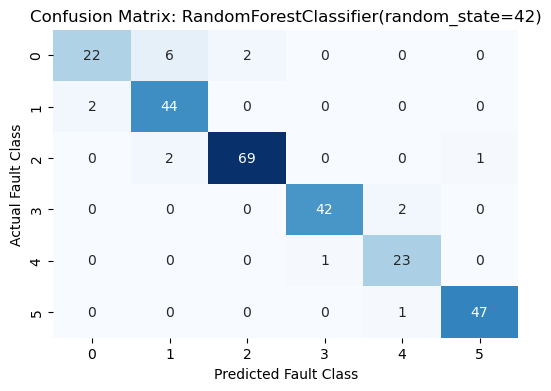

Random Forest Accuracy: 0.9356060606060606
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.73      0.81        30
           2       0.85      0.96      0.90        46
           3       0.97      0.96      0.97        72
           4       0.98      0.95      0.97        44
           5       0.88      0.96      0.92        24
           6       0.98      0.98      0.98        48

    accuracy                           0.94       264
   macro avg       0.93      0.92      0.92       264
weighted avg       0.94      0.94      0.93       264



In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)




importances = rf_model.feature_importances_
feature_names = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']

feature_importance_df = pd.DataFrame({
    'Gas': feature_names,
    'Importance': importances
})
ture_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Gas', data=feature_importance_df, palette='viridis')
plt.title('Which Gases Best Predict Transformer Faults?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Dissolved Gas', fontsize=12)
plt.tight_layout()
plt.show()




rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {rf_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("Random Forest Accuracy:", rf_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, rf_y_pred))

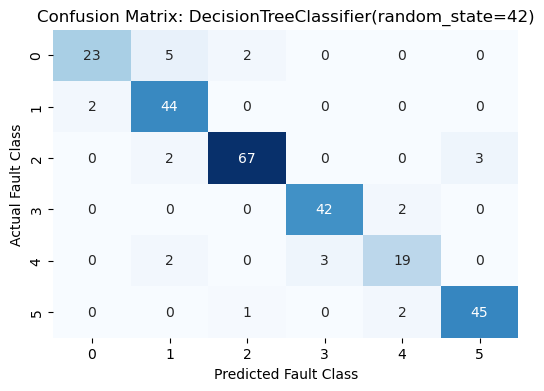

Decision Tree Classifier Accuracy: 0.9090909090909091
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.77      0.84        30
           2       0.83      0.96      0.89        46
           3       0.96      0.93      0.94        72
           4       0.93      0.95      0.94        44
           5       0.83      0.79      0.81        24
           6       0.94      0.94      0.94        48

    accuracy                           0.91       264
   macro avg       0.90      0.89      0.89       264
weighted avg       0.91      0.91      0.91       264



In [16]:
df_model = DecisionTreeClassifier(random_state=42)
df_model.fit(X_train, y_train)
df_y_pred = df_model.predict(X_test)

df_cm = confusion_matrix(y_test, df_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {df_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


df_accuracy = accuracy_score(y_test, df_y_pred)
print("Decision Tree Classifier Accuracy:", df_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, df_y_pred))

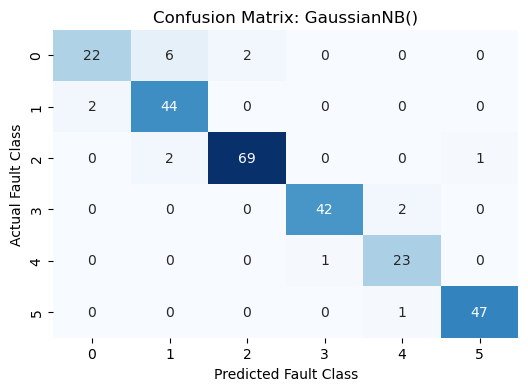

Naive Bayes Accuracy: 0.3446969696969697
              precision    recall  f1-score   support

           1       0.78      0.23      0.36        30
           2       0.28      0.46      0.35        46
           3       0.69      0.15      0.25        72
           4       0.30      1.00      0.46        44
           5       0.12      0.04      0.06        24
           6       0.88      0.15      0.25        48

    accuracy                           0.34       264
   macro avg       0.51      0.34      0.29       264
weighted avg       0.54      0.34      0.30       264



In [17]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
gnb_y_pred = gnb_model.predict(X_test)

gnb_cm = confusion_matrix(y_test, gnb_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {gnb_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


gnb_accuracy = accuracy_score(y_test, gnb_y_pred)
print("Naive Bayes Accuracy:", gnb_accuracy)
print(classification_report(y_test, gnb_y_pred))

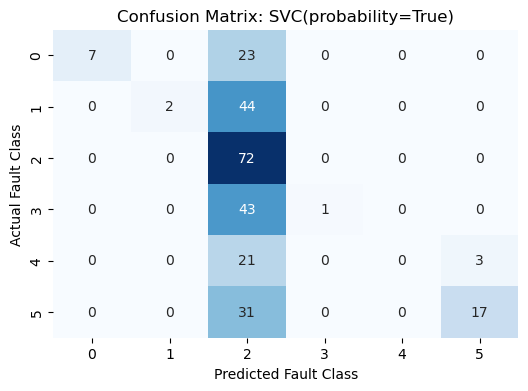

Support Vector Machine Accuracy: 0.375
Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.23      0.38        30
           2       1.00      0.04      0.08        46
           3       0.31      1.00      0.47        72
           4       1.00      0.02      0.04        44
           5       0.00      0.00      0.00        24
           6       0.85      0.35      0.50        48

    accuracy                           0.38       264
   macro avg       0.69      0.28      0.25       264
weighted avg       0.69      0.38      0.28       264



In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_y_pred = svm_model.predict(X_test_scaled)

svm_cm = confusion_matrix(y_test, svm_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {svm_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


svm_accuracy = accuracy_score(y_test, svm_y_pred)
print("Support Vector Machine Accuracy:", svm_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, svm_y_pred,zero_division=0))

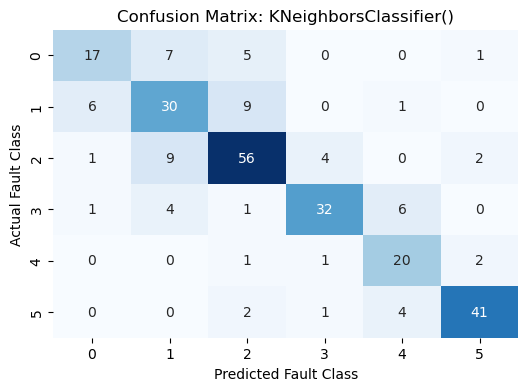

K-Nearest Neighbors Accuracy: 0.7424242424242424
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.57      0.62        30
           2       0.60      0.65      0.62        46
           3       0.76      0.78      0.77        72
           4       0.84      0.73      0.78        44
           5       0.65      0.83      0.73        24
           6       0.89      0.85      0.87        48

    accuracy                           0.74       264
   macro avg       0.74      0.74      0.73       264
weighted avg       0.75      0.74      0.74       264



In [19]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_y_pred = knn_model.predict(X_test_scaled)

knn_cm = confusion_matrix(y_test, knn_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {knn_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


knn_accuracy = accuracy_score(y_test, knn_y_pred)
print("K-Nearest Neighbors Accuracy:", knn_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, knn_y_pred,zero_division=0))

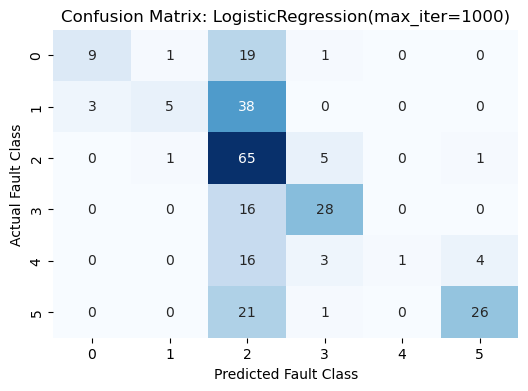

Logistic Regression Accuracy: 0.5075757575757576
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.30      0.43        30
           2       0.71      0.11      0.19        46
           3       0.37      0.90      0.53        72
           4       0.74      0.64      0.68        44
           5       1.00      0.04      0.08        24
           6       0.84      0.54      0.66        48

    accuracy                           0.51       264
   macro avg       0.74      0.42      0.43       264
weighted avg       0.68      0.51      0.47       264



In [20]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_y_pred = lr_model.predict(X_test_scaled)

lr_cm = confusion_matrix(y_test, lr_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {lr_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


lr_accuracy = accuracy_score(y_test, lr_y_pred)
print("Logistic Regression Accuracy:", lr_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, lr_y_pred,zero_division=0))

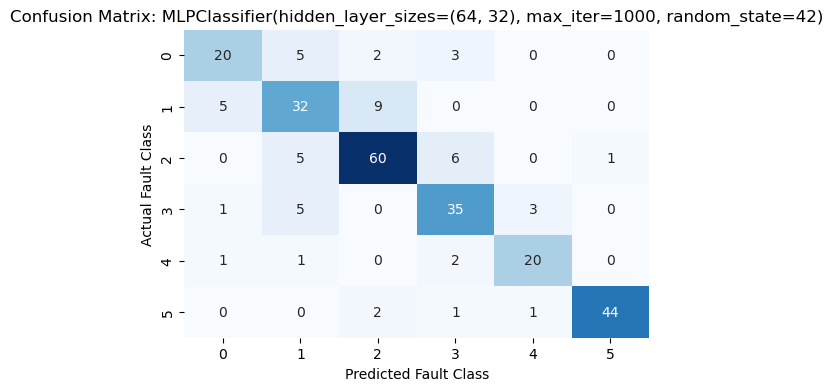

Artificial Neural Network Accuracy: 0.7992424242424242
Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.67      0.70        30
           2       0.67      0.70      0.68        46
           3       0.82      0.83      0.83        72
           4       0.74      0.80      0.77        44
           5       0.83      0.83      0.83        24
           6       0.98      0.92      0.95        48

    accuracy                           0.80       264
   macro avg       0.80      0.79      0.79       264
weighted avg       0.80      0.80      0.80       264



In [21]:
ann_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42)
ann_model.fit(X_train_scaled, y_train)
ann_y_pred = ann_model.predict(X_test_scaled)

ann_cm = confusion_matrix(y_test, ann_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {ann_model}')
plt.xlabel('Predicted Fault Class')
plt.ylabel('Actual Fault Class')
plt.show()


ann_accuracy = accuracy_score(y_test, ann_y_pred)
print("Artificial Neural Network Accuracy:", ann_accuracy)

print("Detailed Classification Report:")
print(classification_report(y_test, ann_y_pred,zero_division=0))

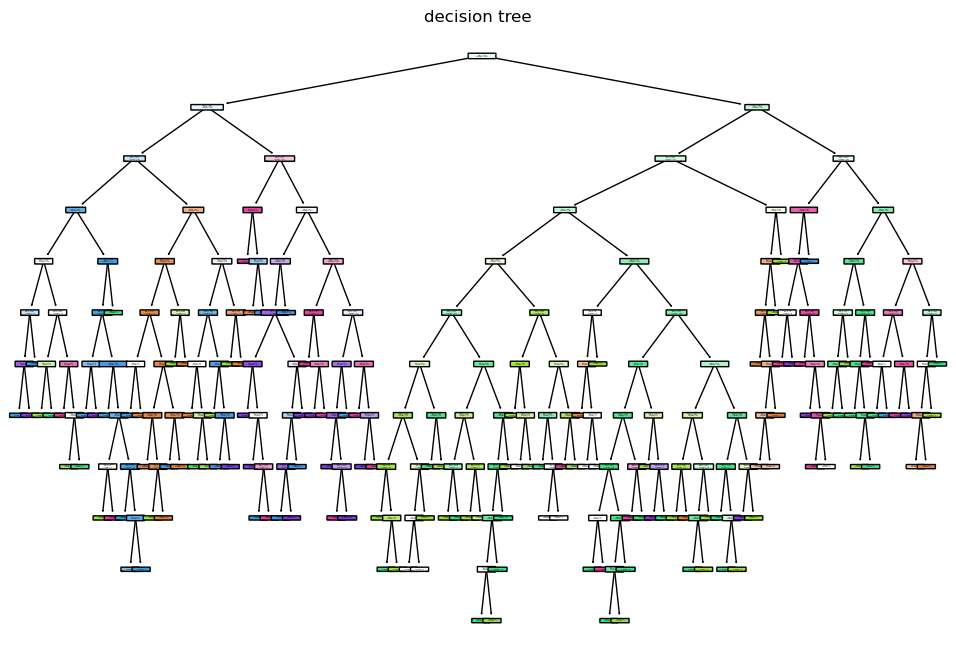

In [22]:
plt.figure(figsize=(12,8))
plot_tree(df_model,
          feature_names=['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2'],
          filled=True,
          rounded=True)

plt.title('decision tree')
plt.show()

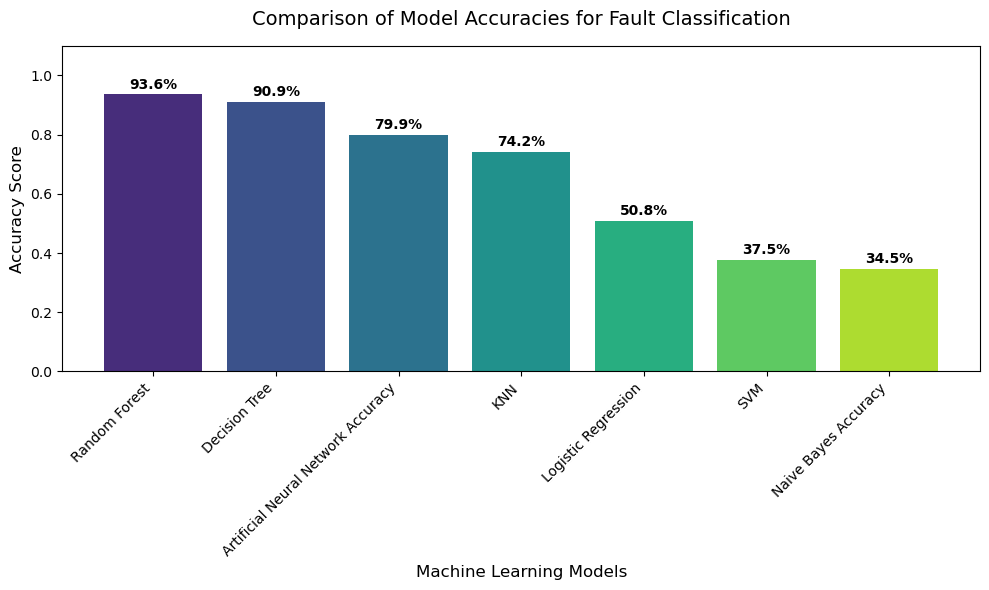

In [23]:
model_accuracies = {
    'Random Forest':rf_accuracy ,
    'Decision Tree':df_accuracy,
    'Naive Bayes Accuracy': gnb_accuracy,
    'SVM': svm_accuracy,
    'Logistic Regression':lr_accuracy,
    'Artificial Neural Network Accuracy': ann_accuracy,
    'KNN':knn_accuracy
} 

sorted_models = dict(sorted(model_accuracies.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_models.keys(), sorted_models.values(), color=sns.color_palette("viridis", len(sorted_models)))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Comparison of Model Accuracies for Fault Classification', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylim(0, 1.1) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
new_data = pd.read_csv("predict_dataset.csv")

feature_cols = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2'] 
X_new = new_data[feature_cols]

X_new_scaled = scaler.transform(X_new)

print(f"Successfully loaded {len(X_new)} samples.\n")

models = { 1: ("Random_Forest", rf_model.predict(X_new)), 
          2: ("Decision_Tree", df_model.predict(X_new)), 
          3: ("Naive_Bayes", gnb_model.predict(X_new)), 
          4: ("SVM", svm_model.predict(X_new_scaled)), 
          5: ("KNN", knn_model.predict(X_new_scaled)), 
          6: ("Logistic_Reg", lr_model.predict(X_new_scaled)), 
          7: ("ANN", ann_model.predict(X_new_scaled)) }

print("Select which predicted dataset you want to download:\n") 
print("1 - Random Forest") 
print("2 - Decision Tree") 
print("3 - Naive Bayes") 
print("4 - SVM") 
print("5 - KNN") 
print("6 - Logistic Regression") 
print("7 - ANN\n")

choice = int(input("Enter number(1-7) to download which predicted dataset you want: "))

if choice in models:
    model_name, predictions = models[choice]

    df_to_save = new_data.copy()
    df_to_save['Predicted_Fault_Class'] = predictions

    filename = f"predictions_{model_name}.csv"
    df_to_save.to_csv(filename, index=False)
    print(f"\nFile saved successfully: {filename}")


    df_for_master = new_data.copy()
    df_for_master['Fault class'] = predictions  
    master_cols = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'Fault class']
    df_for_master = df_for_master[master_cols]
    updated_combined_df = pd.concat([combined_df, df_for_master], ignore_index=True)
    updated_combined_df.to_csv(MASTER_FILE, index=False)
    print(f"Successfully updated '{MASTER_FILE}'! The dataset now has {len(updated_combined_df)} samples.")

else: 
    print("Invalid selection.")

Successfully loaded 589 samples.

Select which predicted dataset you want to download:

1 - Random Forest
2 - Decision Tree
3 - Naive Bayes
4 - SVM
5 - KNN
6 - Logistic Regression
7 - ANN

